In [2]:
import joblib
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

model = joblib.load("logreg_model.pkl")
X_test = joblib.load("X_test.pkl")
y_test = joblib.load("y_test.pkl")


In [3]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # 1 sınıfının olasılığı


In [4]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[175,  14],
       [ 48,  25]])


### N/FP Trade-off (Takas)

In [5]:
#Classification Report (Precision/Recall/F1)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.78      0.93      0.85       189
           1       0.64      0.34      0.45        73

    accuracy                           0.76       262
   macro avg       0.71      0.63      0.65       262
weighted avg       0.74      0.76      0.74       262



In [6]:
auc = roc_auc_score(y_test, y_proba)
auc


0.7807494382836849

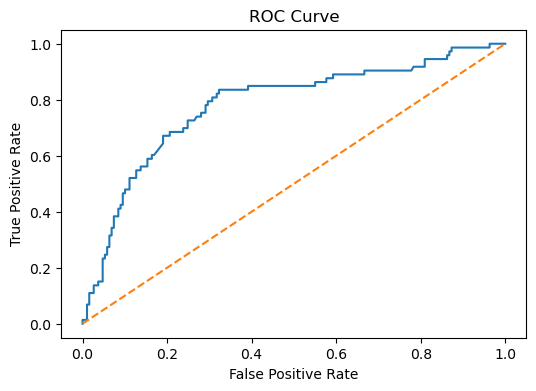

In [7]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()


In [9]:
df = pd.read_csv("titanic_featureeng.csv")
features = ["Pclass","Sex","Age","Fare_log","FamilySize","IsAlone"]
X = df[features]
y = df["2urvived"]


In [10]:
scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
scores, scores.mean()


(array([0.79389313, 0.83969466, 0.80916031, 0.71755725, 0.7164751 ]),
 np.float64(0.7753560878593782))

### Model accuracy metrikinin yanında precision/recall/f1 skorlarıyla da değerlendirildi. Confusion matrix, modelin hangi hata tiplerinde zorlandığını gösterdi. ROC-AUC skoru modelin sınıfları ayırma gücünü ölçtü. 5-fold cross-validation ile performansın genel veri üzerinde daha stabil olduğu doğrulandı.

In [11]:
import joblib

joblib.dump(model, "logreg_baseline.pkl")
joblib.dump(X, "X_full.pkl")
joblib.dump(y, "y_full.pkl")


['y_full.pkl']